In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import sem, t
from sklearn.metrics import r2_score
from sklearn.metrics.pairwise import cosine_similarity

# ----------------- 全局参数（调参只需改这里） -----------------
n_folds        = 10
embed_dir      = '../k_folds_model/embeddings'
pred_dir       = '../k_folds_model/xgb_predictions'  # 预测结果路径

# 权重函数参数，对应公式 S2 中的 a 和 ε
A      = 10.0
EPS       = 1e-6

# 网格分辨率（ρ_s cutoff 与 I_A cutoff）
GRID_SIZE      = 40

def weight_func(sim, a=A, epsilon=EPS):
    """
    输入相似度 sim（可以是标量或 array, 期望在 [-1,1]，会 clamp 到 [0,1]）,
    返回 w = exp(-a * (1 - S) / (S + ε))
    """
    s = np.clip(sim, 0.0, 1.0)  # 保证在 [0,1]
    return np.exp(-a * (1 - s) / (s + epsilon))

# ------------- 计算训练集中每个 t 的 S_WD,t（公式 S4） -------------
def compute_SWD_full(X_train, y_train, a=A, epsilon=EPS):
    """
    输入：
        X_train: (N, D) 训练集嵌入
        y_train: (N,)  真实标签
    输出：
        SWD: (N,) 每个训练分子的加权局部不连续性评分 S_WD,t
    参照公式 S4，v 遍历训练集除 t 本身的所有点
    """
    # 1. 训练集两两余弦相似度 S_{M, t, v}
    sim_tt = cosine_similarity(X_train)  # (N, N)
    sim_tt = np.clip(sim_tt, 0.0, 1.0)

    # 2. 权重 w_{t,v}
    W = weight_func(sim_tt, a=a, epsilon=epsilon)  # (N, N)
    np.fill_diagonal(W, 0.0)  # 排除自身

    # 3. 差值 |y_t - y_v|
    diff = np.abs(y_train[:, None] - y_train[None, :])  # (N, N)

    # 4. numerator 和 denominator
    numer = (W * sim_tt * diff).sum(axis=1)  # Σ_v w_{t,v} * S_{M,t,v} * |y_t - y_v|
    denom = W.sum(axis=1) + epsilon          # Σ_v w_{t,v} + ε
    SWD = numer / denom  # (N,)

    return SWD  # S_WD,t

# ------------- 计算 query 的 ρₛ 和 I_A（公式 S1 + S3） -------------
def compute_rho_and_IA_AD_SAL(X_train, y_train, X_query, a=A, epsilon=EPS):
    """
    输入：
        X_train: (N, D) 训练集嵌入
        y_train: (N,)  训练标签
        X_query: (M, D) 查询/测试嵌入
    输出（归一化前）：
        rho_s: (M,) 公式 S1 (sum of weights)
        IA:    (M,) 公式 S3（加权 SWD 平均）
    然后分别对 rho_s 和 IA 做 min-max 归一化到 [0,1] 以满足文档最后一句。
    """
    # 1. 训练集的 SWD,t
    SWD = compute_SWD_full(X_train, y_train, a=a, epsilon=epsilon)  # (N,)

    # 2. query-to-train 相似度
    sim_qt = cosine_similarity(X_query, X_train)  # (M, N)
    sim_qt = np.clip(sim_qt, 0.0, 1.0)

    # 3. 对每个 (q,t) 计算权重 w_{q,t}
    w_qt = weight_func(sim_qt, a=a, epsilon=epsilon)  # (M, N)

    # 4. ρₛ,q = Σ_t w_{q,t}  （未归一化）
    rho_s_raw = w_qt.sum(axis=1)  # (M,)

    # 5. I_A,q = (Σ_t w_{q,t} * S_WD,t) / (Σ_t w_{q,t})
    IA_raw = (w_qt * SWD[None, :]).sum(axis=1) / (w_qt.sum(axis=1) + epsilon)  # (M,)

    # 6. min-max 归一化到 [0,1]（分别对 rho_s 和 IA independent）
    def minmax(arr):
        lo = np.nanmin(arr)
        hi = np.nanmax(arr)
        if hi - lo < 1e-12:
            return np.zeros_like(arr)  # 全一样的退回 0
        return (arr - lo) / (hi - lo)

    rho_s = minmax(rho_s_raw)
    IA    = minmax(IA_raw)

    return rho_s, IA, rho_s_raw, IA_raw  # 返回归一化后的和原始的（便于 debug/可视化）

# ----------------- 收集所有 fold 上的 ρₛ/IA 用于确定 cutoff 范围 -----------------
all_rho = []
all_IA  = []
for fold in range(1, n_folds+1):
    X_tr = np.load(os.path.join(embed_dir, f'train_fold_{fold}.npy'))[:, :768]
    y_tr = np.load(os.path.join(embed_dir, f'train_labels_fold_{fold}.npy'))
    X_te = np.load(os.path.join(embed_dir, f'val_fold_{fold}.npy'))[:, :768]

    rho_s, IA = compute_rho_IA_full(X_tr, y_tr, X_te)
    all_rho.append(rho_s)
    all_IA.append(IA)

all_rho = np.concatenate(all_rho)
all_IA  = np.concatenate(all_IA)

# 用分位数（例如 5%-95%）设定网格边界以避免极端
rho_low, rho_high = np.percentile(all_rho, [5, 95])
IA_low,  IA_high  = np.percentile(all_IA,  [5, 95])

rho_cuts = np.linspace(rho_low, rho_high, GRID_SIZE)
IA_cuts  = np.linspace(IA_low,  IA_high,  GRID_SIZE)

# ----------------- 十折网格统计：AD 内 / AD 外 -----------------
mean_n      = np.zeros((GRID_SIZE, GRID_SIZE))
mean_r2_in  = np.zeros((GRID_SIZE, GRID_SIZE))
mean_r2_out = np.zeros((GRID_SIZE, GRID_SIZE))
counts_list, r2in_list, r2out_list = [], [], []

for fold in range(1, n_folds+1):
    X_tr = np.load(os.path.join(embed_dir, f'train_fold_{fold}.npy'))[:, :768]
    y_tr = np.load(os.path.join(embed_dir, f'train_labels_fold_{fold}.npy'))
    X_te = np.load(os.path.join(embed_dir, f'val_fold_{fold}.npy'))[:, :768]
    y_te = np.load(os.path.join(embed_dir, f'val_labels_fold_{fold}.npy'))
    y_pr= np.load(os.path.join(pred_dir, f'fold_{fold}_y_pred.npy'))

    rho_s, IA = compute_rho_IA_full(X_tr, y_tr, X_te)

    cnt   = np.zeros_like(mean_n)
    r2in  = np.zeros_like(mean_n)
    r2out = np.zeros_like(mean_n)

    for i, ia_th in enumerate(IA_cuts):
        for j, rho_th in enumerate(rho_cuts):
            in_m  = (rho_s >= rho_th) & (IA <= ia_th)
            out_m = ~in_m
            cnt[i,j] = in_m.sum()
            if in_m.sum() > 1:
                r2in[i,j] = r2_score(y_te[in_m], y_pr[in_m])
            if out_m.sum() > 1:
                r2out[i,j] = r2_score(y_te[out_m], y_pr[out_m])
            mean_n[i,j]     += cnt[i,j]
            mean_r2_in[i,j] += np.nan_to_num(r2in[i,j])
            mean_r2_out[i,j]+= np.nan_to_num(r2out[i,j])

    counts_list.append(cnt)
    r2in_list.append(r2in)
    r2out_list.append(r2out)

# 十折平均
mean_n      /= n_folds
mean_r2_in  /= n_folds
mean_r2_out /= n_folds

# ----------------- 计算 95% 置信区间 -----------------
counts_arr = np.stack(counts_list, axis=0)   # shape (fold, G, G)
r2in_arr   = np.stack(r2in_list,   axis=0)
r2out_arr  = np.stack(r2out_list,  axis=0)
tval       = t.ppf(0.975, df=n_folds-1)

ci_n       = sem(counts_arr, axis=0, nan_policy='omit') * tval
ci_r2in    = sem(r2in_arr,   axis=0, nan_policy='omit') * tval
ci_r2out   = sem(r2out_arr,  axis=0, nan_policy='omit') * tval

# ----------------- 导出 CSV -----------------
records = []
# 用最后一 fold 的测试集大小作为 N_test（各 fold 应当一致）
N_test = X_te.shape[0]
for i, ia_th in enumerate(IA_cuts):
    for j, rho_th in enumerate(rho_cuts):
        records.append({
            'rho_th':      rho_th,
            'IA_th':       ia_th,
            'count_in':    mean_n[i,j],
            'count_in_CI': ci_n[i,j],
            'count_out':   N_test - mean_n[i,j],
            'r2_in':       mean_r2_in[i,j],
            'r2in_CI':     ci_r2in[i,j],
            'r2_out':      mean_r2_out[i,j],
            'r2out_CI':    ci_r2out[i,j],
        })
df = pd.DataFrame(records)
df.to_csv('AD_SAL.csv', index=False)
print("导出完毕：AD_SAL.csv")


导出完毕：AD_SAL.csv


In [13]:
# ----------------- 绘图 -----------------
X_mesh, Y_mesh = np.meshgrid(rho_cuts, IA_cuts)

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as pe

# 假设 X_mesh, Y_mesh, mean_r2, mean_r2_out, rho_best, ia_best, r2_in_best, r2_out_best 已经定义

mean_r2 = mean_r2_in
# 1) 找到“AD 内”的最优阈值点
flat_in = np.nanargmax(mean_r2)
i_best, j_best = np.unravel_index(flat_in, mean_r2.shape)
rho_best = X_mesh[i_best, j_best]
ia_best  = Y_mesh[i_best, j_best]
r2_in_best  = mean_r2[i_best, j_best]
r2_out_best = mean_r2_out[i_best, j_best]

/tmp/ipykernel_1482/3542620194.py:57: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


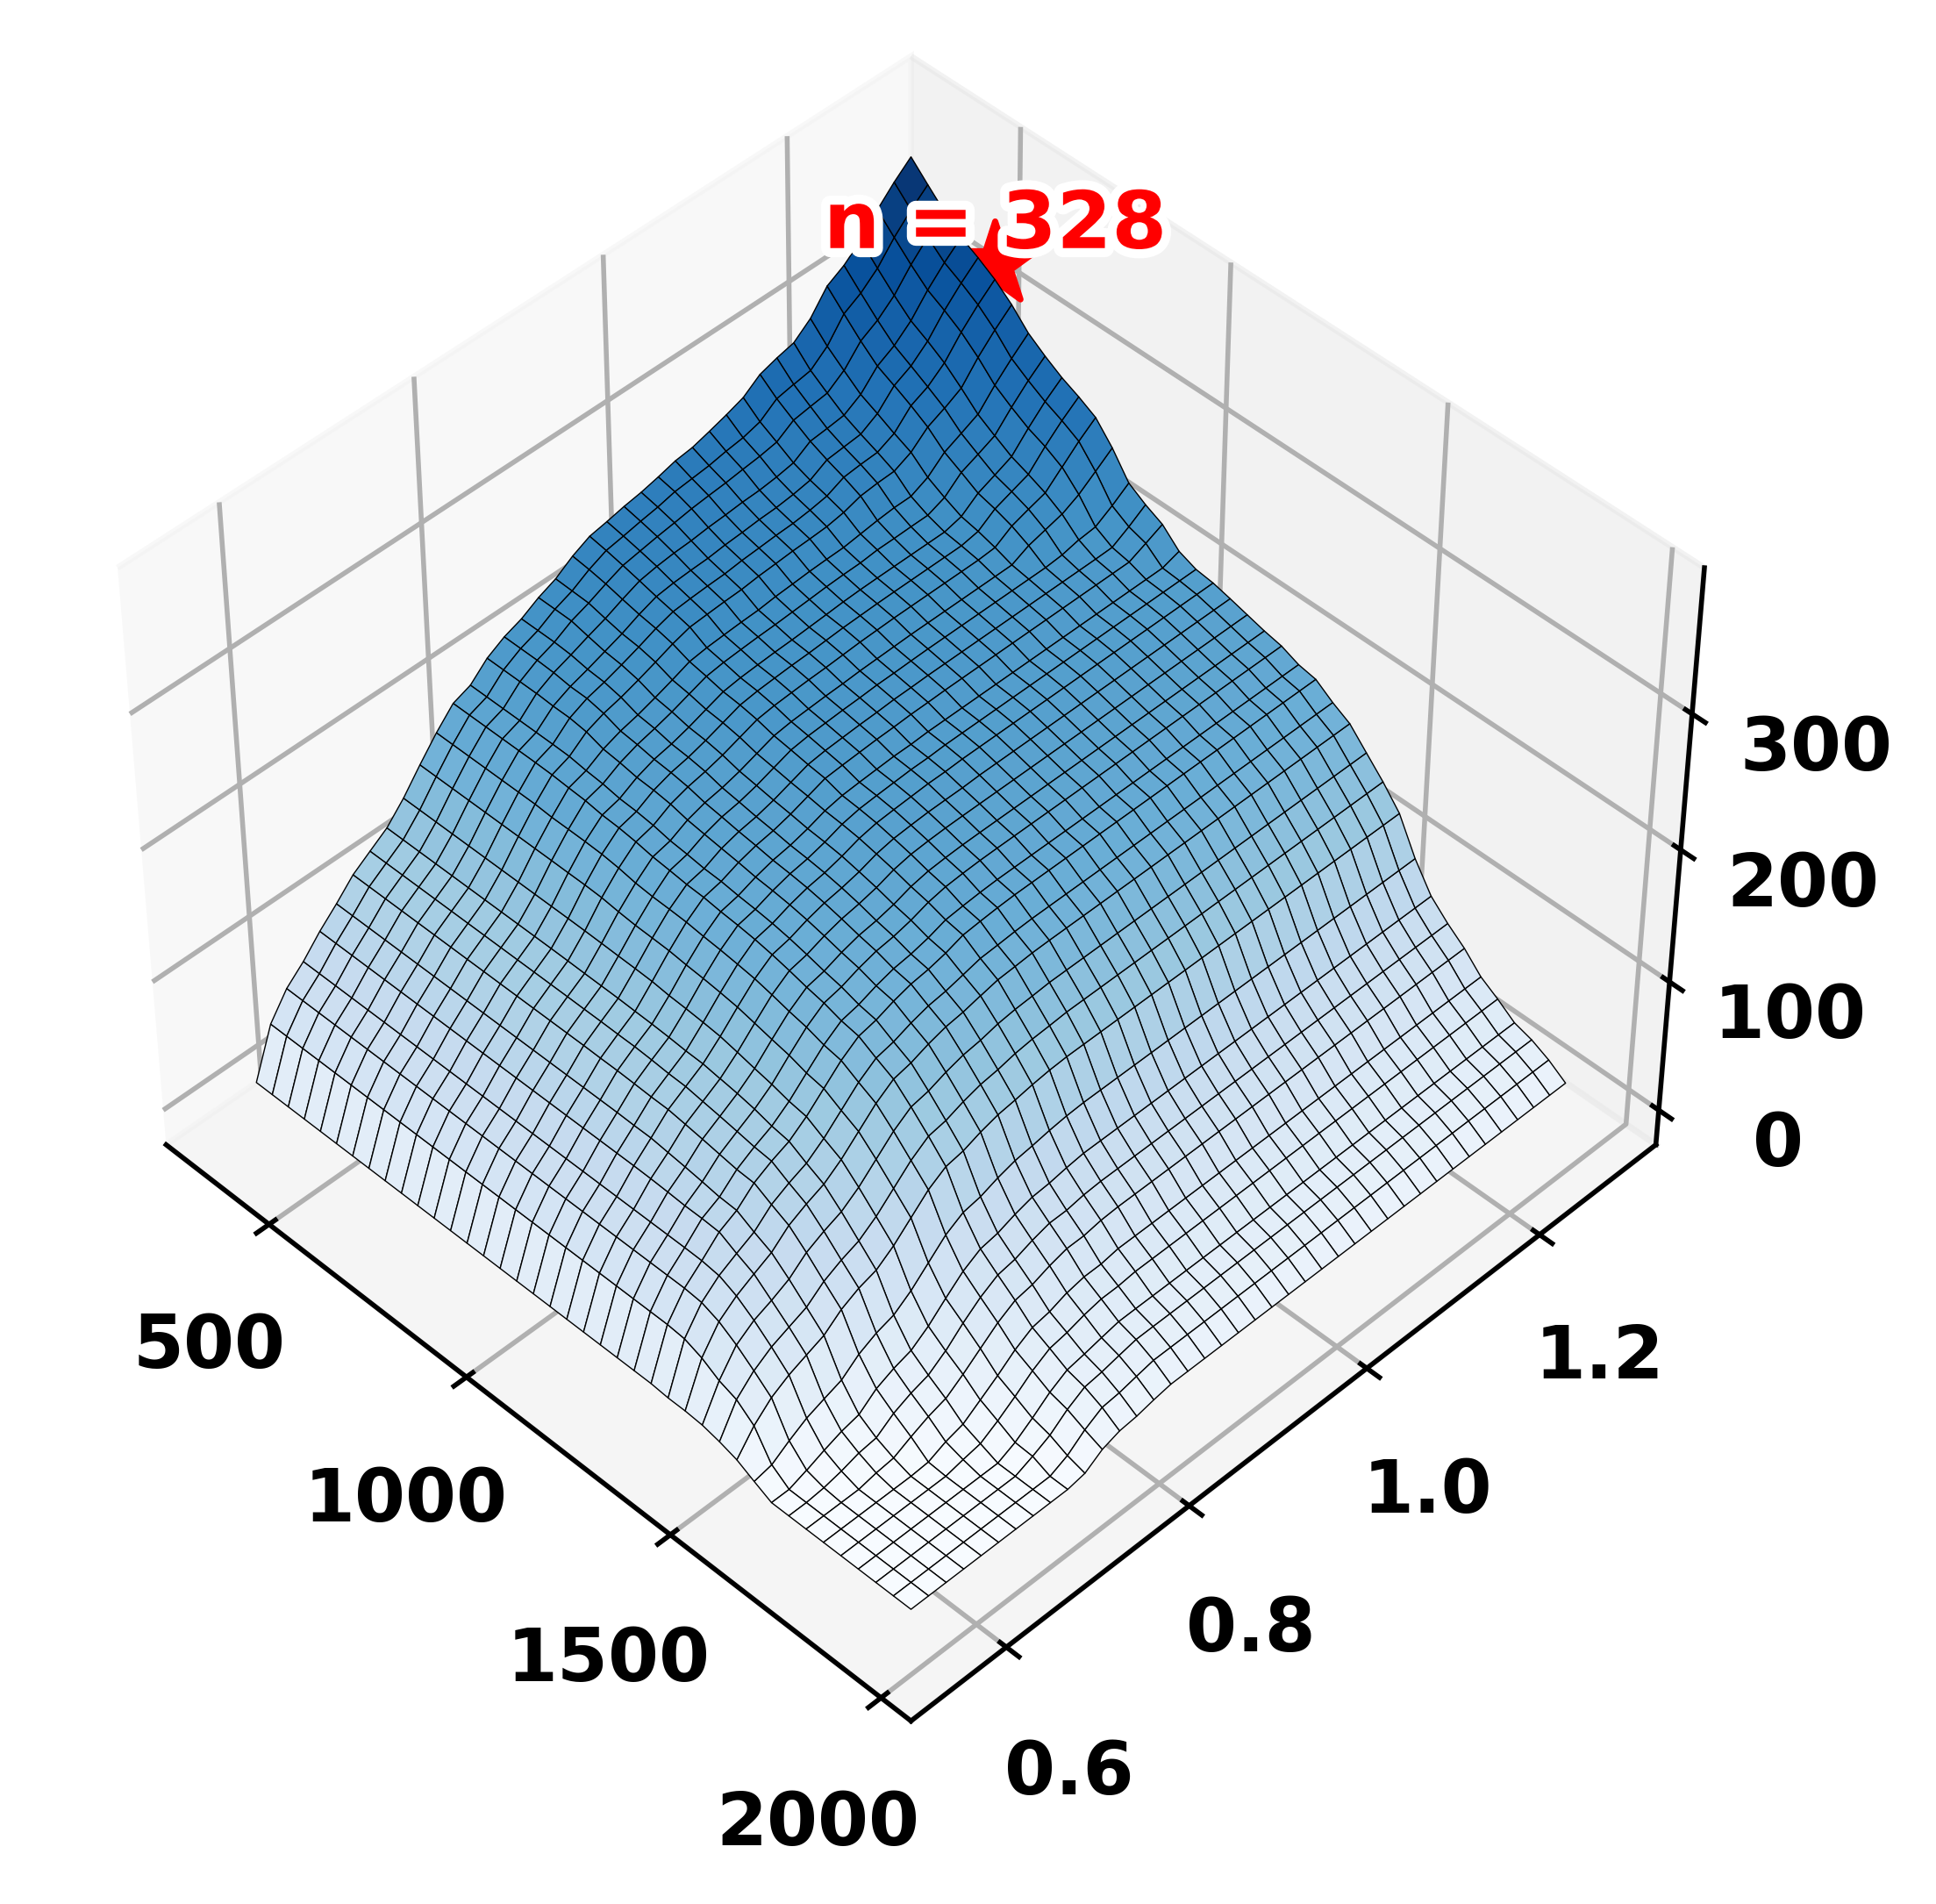

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# 假设 X_mesh, Y_mesh, mean_r2_in, mean_r2_out, mean_n 已经定义

# ——— 1) 先找到“AD 内”R² 最大的阈值组合，同时取出该位置的 n retained ——— #
flat_in = np.nanargmax(mean_r2_in)
i_best, j_best = np.unravel_index(flat_in, mean_r2_in.shape)
rho_best = X_mesh[i_best, j_best]
ia_best  = Y_mesh[i_best, j_best]
n_best   = mean_n[i_best, j_best]   # 对应的样本数

# ——— 绘图 ——— #
fig1 = plt.figure(figsize=(6, 5), dpi=500)
ax1 = fig1.add_subplot(1, 1, 1, projection='3d')

surf1 = ax1.plot_surface(
    X_mesh, Y_mesh, mean_n,
    cmap='Blues',
    edgecolor='k',
    linewidth=0.2,
    antialiased=True,
    vmin=0, vmax=np.nanmax(mean_n)
)

# 坐标轴刻度加粗 & 放大
ax1.tick_params(axis='both', labelsize=12, width=1.5)
for t in ax1.get_xticklabels() + ax1.get_yticklabels() + ax1.get_zticklabels():
    t.set_fontweight('bold')

# 视角
ax1.view_init(elev=45, azim=-45)

# ——— 标注最佳点 ——— #
# 稍微抬高 z 值避免被 surface 遮挡
z_highlight = n_best + (np.nanmax(mean_n) * 0.03)

# 红色五角星
ax1.scatter(
    [rho_best], [ia_best], [z_highlight],
    color='red', s=200, marker='*', depthshade=True, zorder=10
)
# 注释文字
txt = ax1.text(
    rho_best, ia_best, z_highlight + (np.nanmax(mean_n) * 0.03),
    f"n = {int(n_best)}",
    color='red', fontsize=13, fontweight='bold',
    horizontalalignment='center', zorder=11
)
# 白色描边增强可读性
import matplotlib.patheffects as pe
txt.set_path_effects([
    pe.Stroke(linewidth=3, foreground='white'),
    pe.Normal()
])

plt.tight_layout()
plt.show()


/tmp/ipykernel_1482/319189871.py:57: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


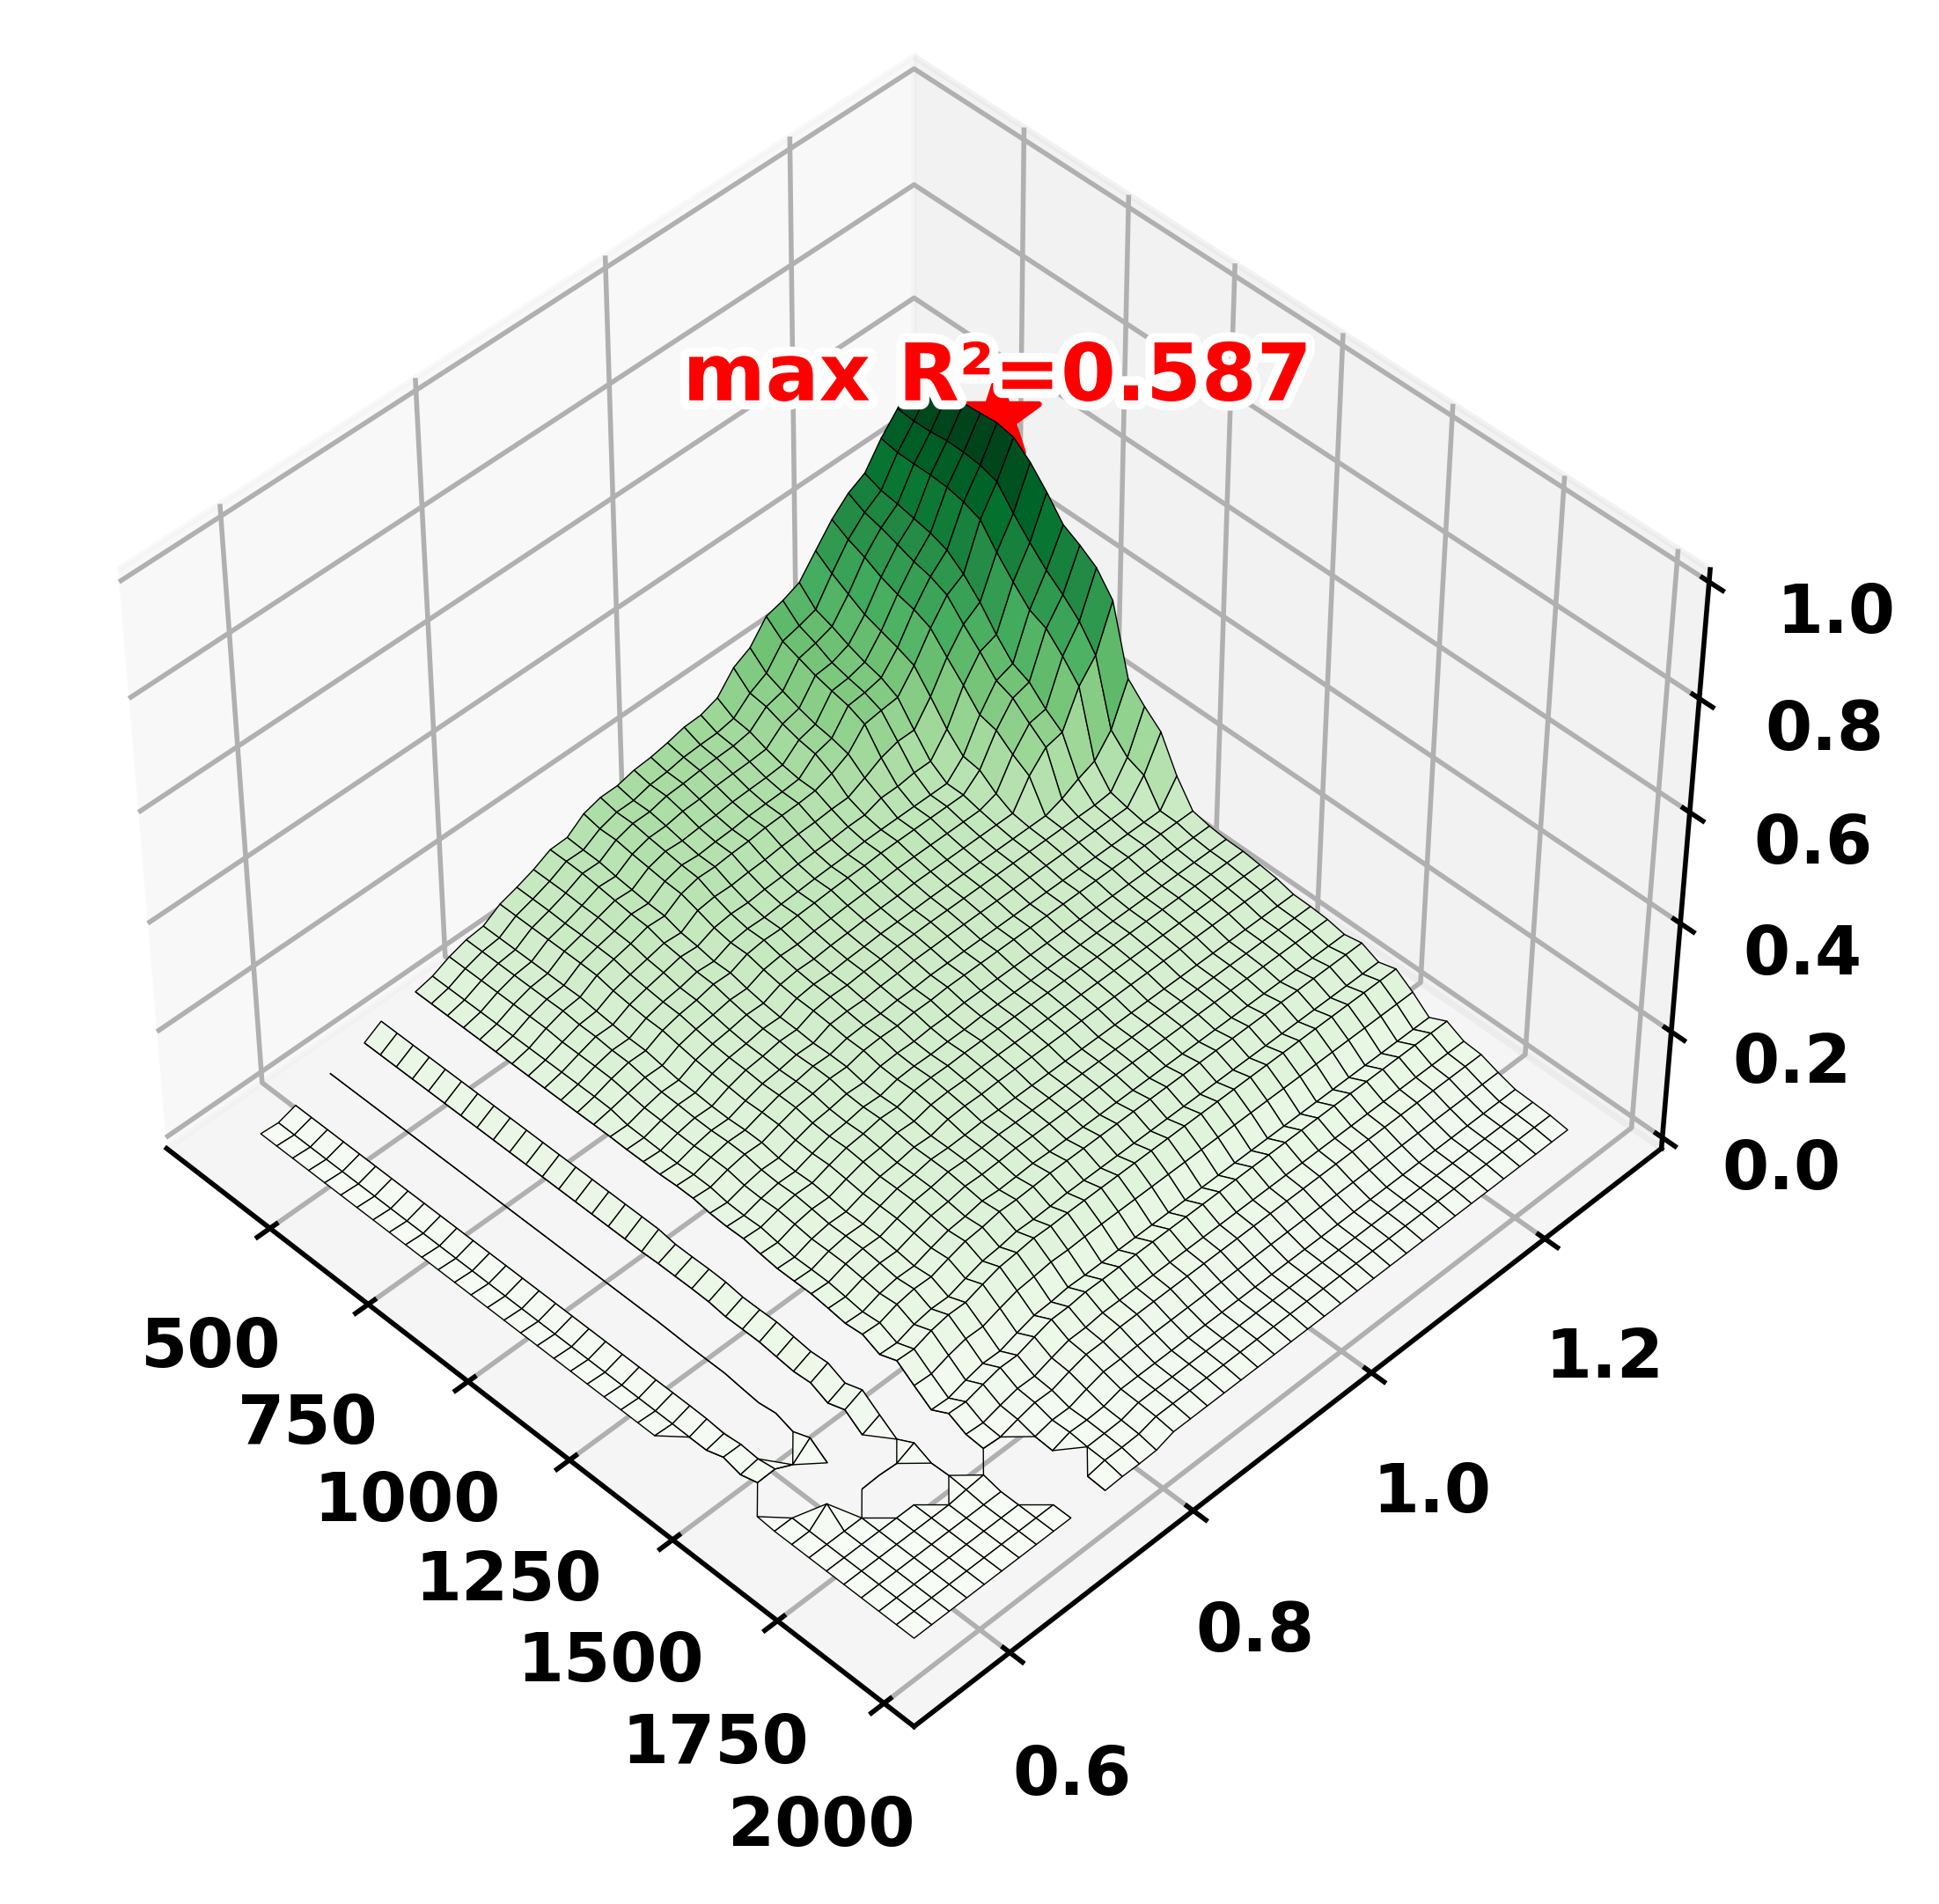

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as pe

fig1 = plt.figure(figsize=(6, 5), dpi=500)
ax1 = fig1.add_subplot(1, 1, 1, projection='3d')

Z_in = np.ma.masked_outside(mean_r2, 0, 1)
surf1 = ax1.plot_surface(
    X_mesh, Y_mesh, Z_in,
    cmap='Greens', edgecolor='k', linewidth=0.2, antialiased=True
)

ax1.set_zlim(0, 1)
# ax1.set_xlabel('ρₛ cutoff', labelpad=15, fontsize=13, fontweight='bold')
# ax1.set_ylabel('Iₐ cutoff', labelpad=15, fontsize=13, fontweight='bold')
# ax1.set_zlabel('R²',        labelpad=15, fontsize=13, fontweight='bold')
# ax1.set_title('R² within AD', pad=20, fontsize=14, fontweight='bold')

# 设置刻度字体加粗和大小
ax1.tick_params(axis='both', labelsize=11, width=1.5)
for t in ax1.get_xticklabels() + ax1.get_yticklabels() + ax1.get_zticklabels():
    t.set_fontweight('bold')

# colorbar
# cbar1 = fig1.colorbar(surf1, ax=ax1, shrink=0.6, pad=0.1)
# cbar1.set_label('R²', fontsize=12, fontweight='bold')
# cbar1.ax.tick_params(labelsize=10)
# for t in cbar1.ax.get_yticklabels():
#     t.set_fontweight('bold')

# best point
# best point (增强可视性)
# best point using five-pointed star marker
highlight_z = r2_in_best + 0.01  # 向上抬高，避免被 surface 遮挡

# 红色五角星标记
ax1.scatter(
    [rho_best], [ia_best], [highlight_z],
    color='red', s=200, marker='*', depthshade=True, zorder=10
)

# 添加文本标注
txt1 = ax1.text(
    rho_best, ia_best, highlight_z + 0.03,
    f"max R²={r2_in_best:.3f}",
    color='red', fontsize=13, fontweight='bold',
    horizontalalignment='center', zorder=11
)
txt1.set_path_effects([
    pe.Stroke(linewidth=3, foreground='white'),
    pe.Normal()
])


ax1.view_init(elev=45, azim=-45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1482/1887777994.py:54: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


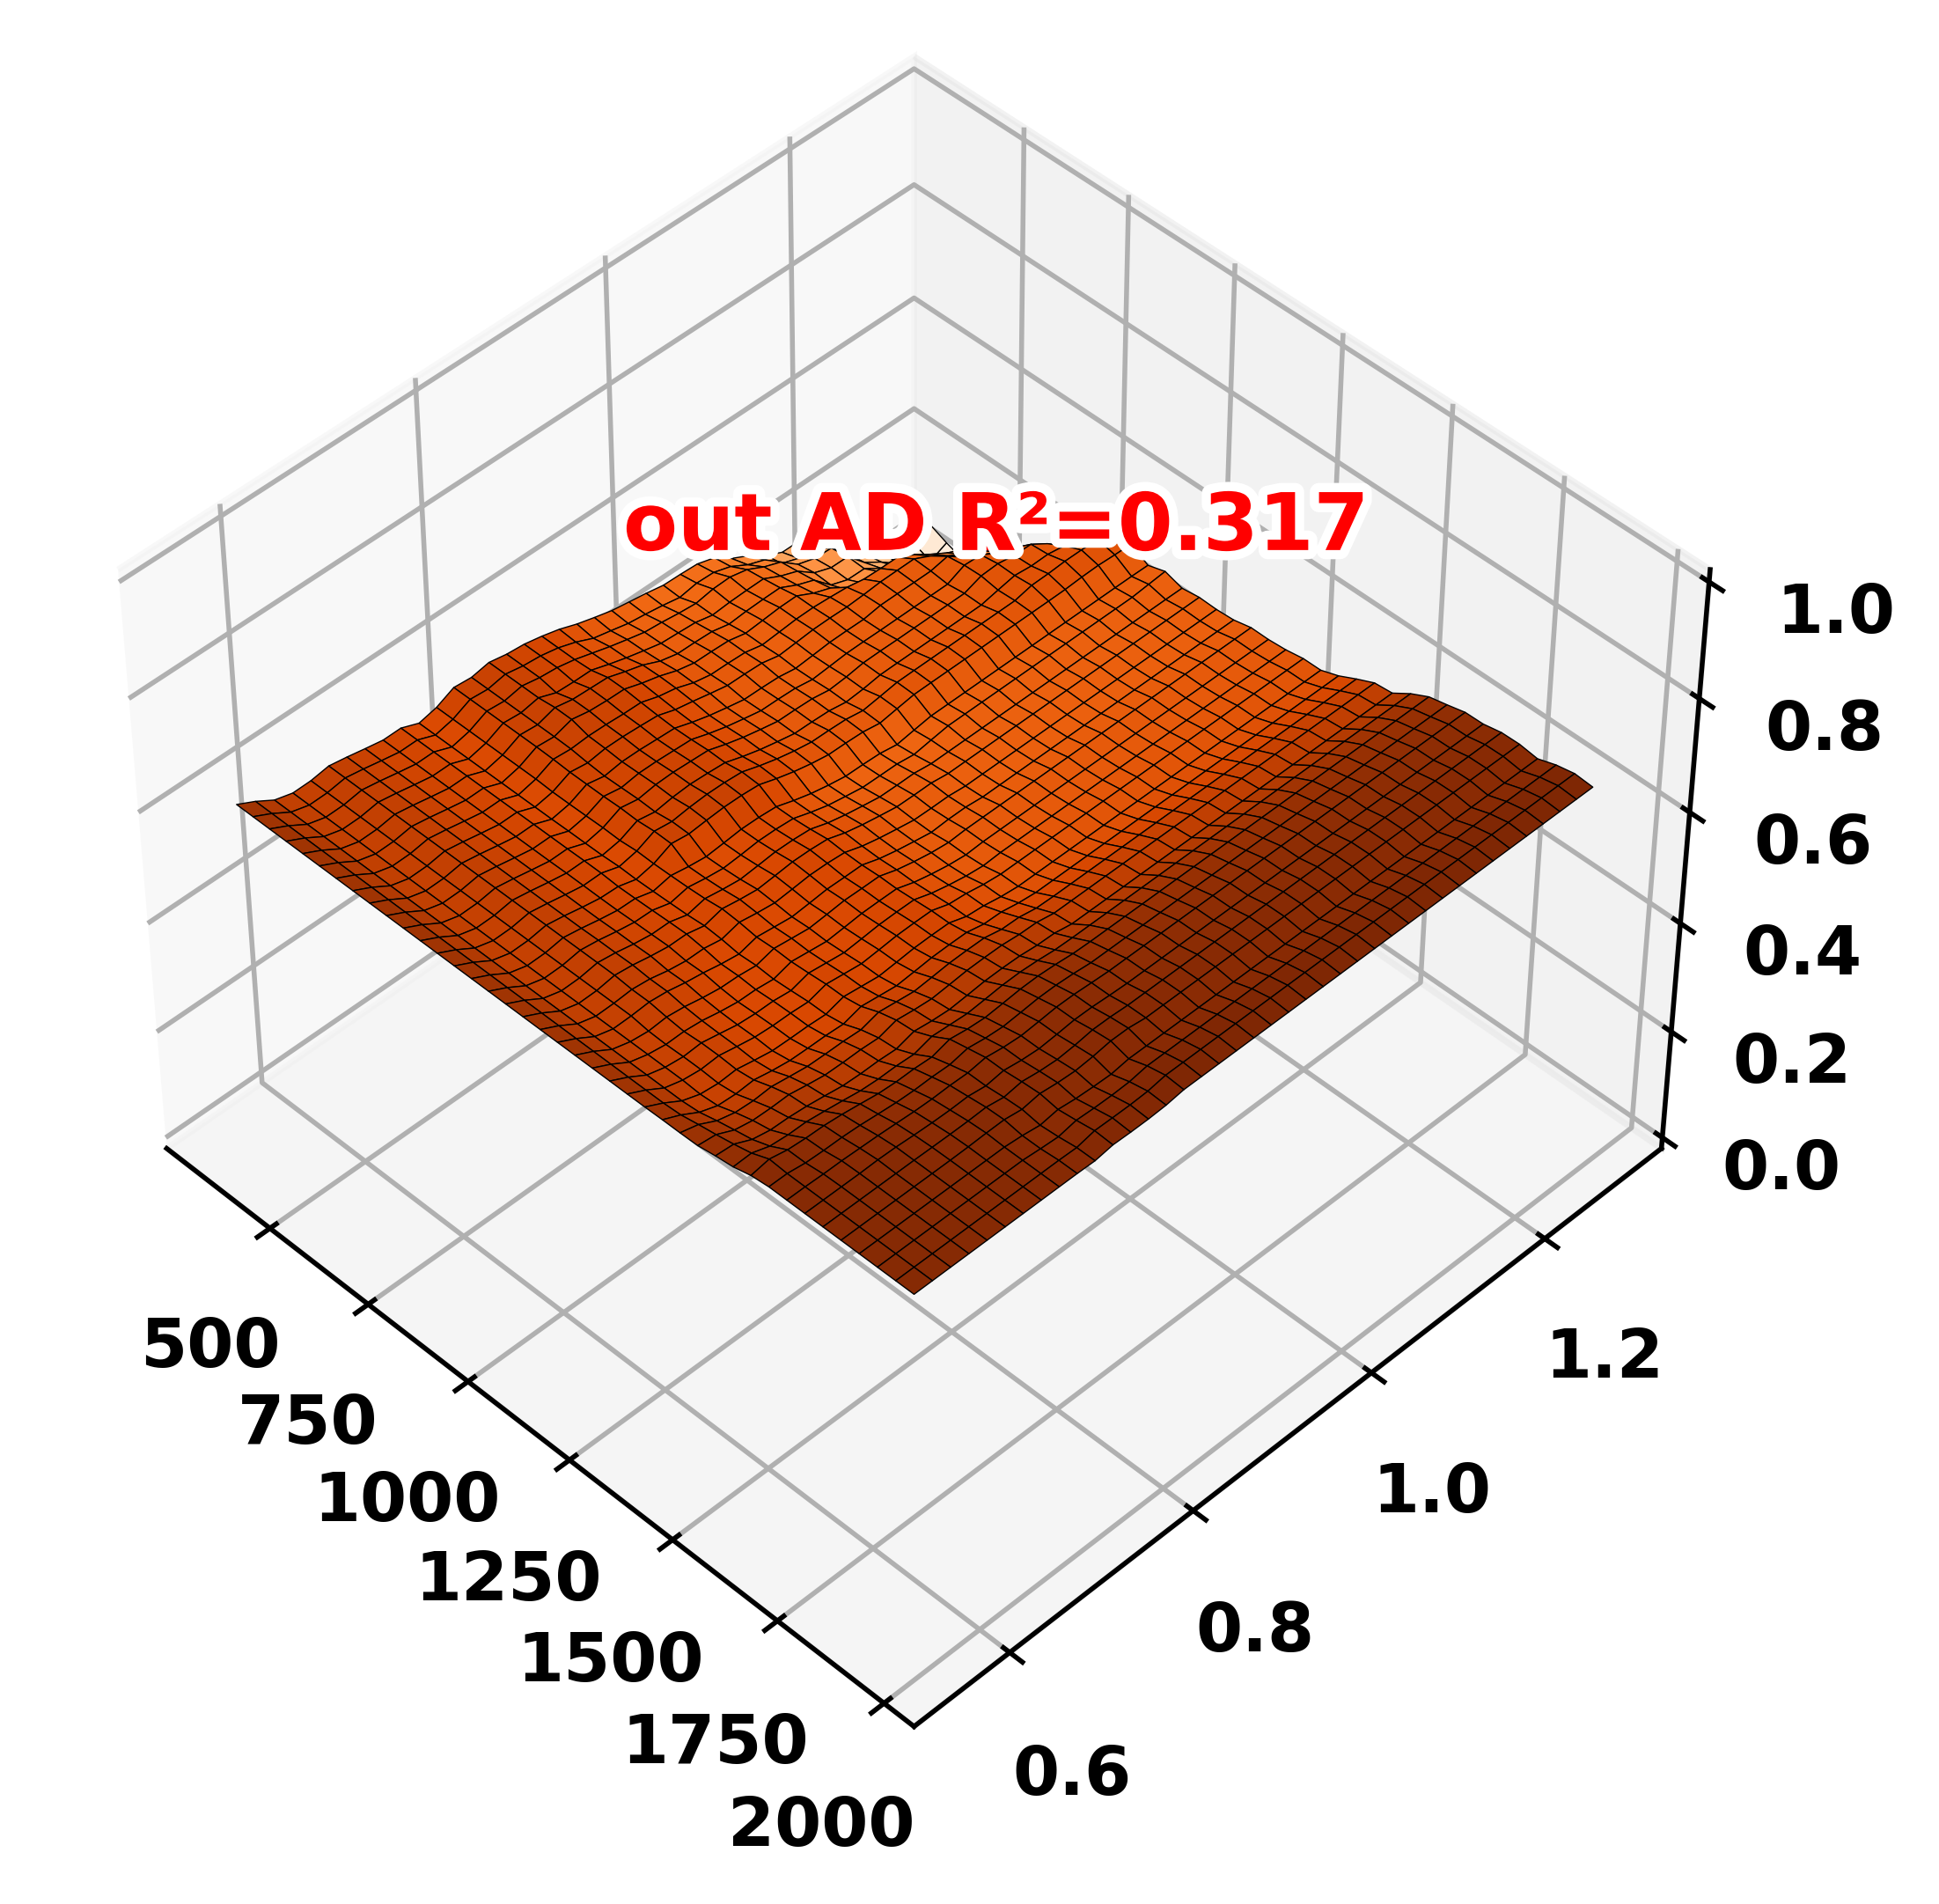

In [17]:
fig2 = plt.figure(figsize=(6, 5), dpi=500)
ax2 = fig2.add_subplot(1, 1, 1, projection='3d')

Z_out = np.ma.masked_outside(mean_r2_out, 0, 1)
surf2 = ax2.plot_surface(
    X_mesh, Y_mesh, Z_out,
    cmap='Oranges', edgecolor='k', linewidth=0.2, antialiased=True
)

ax2.set_zlim(0, 1)
# ax2.set_xlabel('ρₛ cutoff', labelpad=15, fontsize=13, fontweight='bold')
# ax2.set_ylabel('Iₐ cutoff', labelpad=15, fontsize=13, fontweight='bold')
# ax2.set_zlabel('R²',        labelpad=15, fontsize=13, fontweight='bold')
# ax2.set_title('R² outside AD', pad=20, fontsize=14, fontweight='bold')

# 设置刻度字体加粗和大小
ax2.tick_params(axis='both', labelsize=11, width=1.5)
for t in ax2.get_xticklabels() + ax2.get_yticklabels() + ax2.get_zticklabels():
    t.set_fontweight('bold')

# # colorbar
# cbar2 = fig2.colorbar(surf2, ax=ax2, shrink=0.6, pad=0.1)
# cbar2.set_label('R²_out', fontsize=12, fontweight='bold')
# cbar2.ax.tick_params(labelsize=10)
# for t in cbar2.ax.get_yticklabels():
#     t.set_fontweight('bold')

# best point
# best point using red five-pointed star
highlight_z_out = r2_out_best + 0.01  # 稍微抬高以避免被 surface 遮挡

# 红色五角星标记
ax2.scatter(
    [rho_best], [ia_best], [highlight_z_out],
    color='red', s=200, marker='*', depthshade=True, zorder=10
)

# 标注文字
txt2 = ax2.text(
    rho_best, ia_best, highlight_z_out + 0.03,
    f"out AD R²={r2_out_best:.3f}",
    color='red', fontsize=13, fontweight='bold',
    horizontalalignment='center', zorder=11
)
txt2.set_path_effects([
    pe.Stroke(linewidth=3, foreground='white'),
    pe.Normal()
])

ax2.view_init(elev=45, azim=-45)
#ax2.view_init(elev=30, azim=-60)


plt.tight_layout()
plt.show()
